In [2]:
import os
import numpy as np
from PIL import Image

# Folder containing your images
folder = "cropped_faces"

# Collect flattened images here
rows = []

for fname in os.listdir(folder):
    if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
        path = os.path.join(folder, fname)
        img = Image.open(path).convert("L")   # "L" makes grayscale, use "RGB" if you want 3 channels
        img = img.resize((127, 127))          # ensures consistent size
        flat = np.array(img).flatten()        # shape (16129,)
        rows.append(flat)

# Final matrix: each row is one flattened image
A = np.vstack(rows)
print("Shape of A:", A.shape)  # (num_images, 16129)


Shape of A: (3279, 16129)


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def show_face(row_vector, size=(127, 127), rgb=False):
    """
    Reconstitute a flattened row vector into an image and display it.
    
    Parameters
    ----------
    row_vector : numpy array (1D)
        Flattened image (length 16129 for grayscale, or 48387 for RGB).
    size : tuple
        (width, height) of the original image.
    rgb : bool
        True if image was stored with 3 channels (RGB), False for grayscale.
    """
    if rgb:
        img = row_vector.reshape(size[1], size[0], 3)  # (127,127,3)
        plt.imshow(img.astype(np.uint8))
    else:
        img = row_vector.reshape(size)  # (127,127)
        plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()


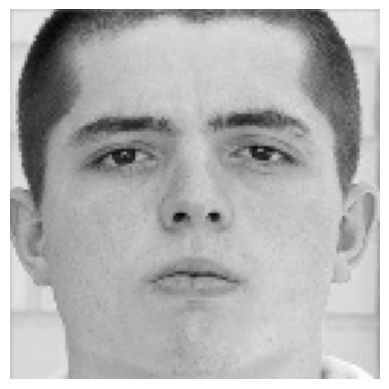

In [5]:
show_face(A[0])